# Feature Processing Playground

This notebook is a sandbox for experimenting with feature groups, dropped columns, derived features, and column-level preprocessing choices. It is designed to make the preprocessing visible rather than hidden.

## 1. Setup

We load the shared modules so the notebook uses the same preprocessing and experiment logic as `src/main.py`.

In [68]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "task-house-prices":
    NOTEBOOK_DIR = Path("/Users/maksymponomarenko/Documents/ai-engineering-kaggle-portfolio/courses/01-machine-learning-with-python/tasks/task-house-prices")

SRC_DIR = NOTEBOOK_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config as config_module
import experiment_config as experiment_config_module
import experiment_runner as experiment_runner_module
import feature_registry as feature_registry_module
import processing_config as processing_config_module
import reporting as reporting_module
import utils as utils_module

for module in [
    config_module,
    experiment_config_module,
    experiment_runner_module,
    feature_registry_module,
    processing_config_module,
    reporting_module,
    utils_module,
]:
    importlib.reload(module)

from config import CONFIG
from experiment_config import ExperimentConfig, project_config_from_experiment, resolve_derived_features
from experiment_runner import apply_feature_builders, run_experiment
from feature_registry import FEATURE_GROUPS
from processing_config import CategoricalProcessingConfig, NumericProcessingConfig, OrdinalProcessingConfig
from reporting import (
    build_after_processing_preview,
    build_before_processing_report,
    build_column_processing_summary,
    build_feature_selection_report,
    build_full_transformed_dataframe,
    build_processing_reference_report,
    transformed_columns_for_source,
)
from utils import collect_configured_features, load_datasets, split_features_target


## 2. Processing Defaults And Alternatives

These tables explain the default processing choices and the main alternatives you can try. The goal is to make preprocessing editable and understandable.

In [69]:
processing_reference = build_processing_reference_report()
processing_reference["numeric_processing_reference"]

,setting,default,alternatives,when_to_use
0,impute_strategy,median,"mean, most_frequent, constant",median is robust to outliers; mean is reasonab...
1,transform,none,"log1p, sqrt",log1p helps right-skewed positive features; sq...
2,scale,none or standard depending on model,"standard, robust, none",standard for linear models; robust when outlie...


In [70]:
processing_reference["categorical_processing_reference"]

,setting,default,alternatives,when_to_use
0,impute_strategy,most_frequent,constant,most_frequent is simple; constant is useful wh...
1,encoding,onehot,documented only,one-hot is the safest default for nominal cate...
2,min_frequency,None,float or int threshold,helps merge rare levels when one-hot columns b...


In [71]:
processing_reference["ordinal_processing_reference"]

,setting,default,alternatives,when_to_use
0,impute_strategy,constant,most_frequent,constant with __MISSING__ is safest when missi...
1,encoding,explicit_ordinal,documented only,ordinal features need an explicit order; wrong...


## 3. Pick Or Edit An Experiment

This is the main editable cell. You can:

- change feature groups
- add or drop columns
- create derived features
- override preprocessing for specific columns
- switch models

In [72]:
experiment = ExperimentConfig(
    name="3 - GarageAreaPerCar: transform=log1p",
    description="GarageAreaPerCar = GarageArea / GarageCars - new feature to capture the relationship between garage size and number of cars it can hold",
    feature_groups=["numeric_core", "ordinal_core", "categorical_core"],
    derived_feature_groups=["engineered_core"],
    add_columns=["TotalSF", "HouseAge", "TotalBathrooms", 
                 "GarageAreaPerCar"],
    drop_columns=["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", 
                  "GarageArea", "GarageCars"],
    model_names=["linear_regression", "ridge", "random_forest"],
    numeric_processing_overrides={
        "LotArea": NumericProcessingConfig(impute_strategy="median", transform="log1p", scale="standard"),
        "GrLivArea": NumericProcessingConfig(impute_strategy="median", transform="log1p", scale="standard"),
        "HouseAge": NumericProcessingConfig(impute_strategy="median", transform="none", scale="standard"),
        "TotalSF": NumericProcessingConfig(impute_strategy="median", transform="none", scale="quantile"),
        "GarageAreaPerCar": NumericProcessingConfig(impute_strategy="constant", fill_value=0, transform="log1p", scale="quantile"),
    },
    categorical_processing_overrides={
        "Neighborhood": CategoricalProcessingConfig(impute_strategy="most_frequent", encoding="onehot", min_frequency=0.01),
    },
    ordinal_processing_overrides={
        "KitchenQual": OrdinalProcessingConfig(impute_strategy="constant", fill_value="__MISSING__", encoding="explicit_ordinal"),
    },
)

experiment

ExperimentConfig(name='3 - GarageAreaPerCar: transform=log1p', description='GarageAreaPerCar = GarageArea / GarageCars - new feature to capture the relationship between garage size and number of cars it can hold', feature_groups=['numeric_core', 'ordinal_core', 'categorical_core'], add_columns=['TotalSF', 'HouseAge', 'TotalBathrooms', 'GarageAreaPerCar'], drop_columns=['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GarageArea', 'GarageCars'], derived_feature_groups=['engineered_core'], derived_features=[], log_transform_columns=None, target_transform=None, numeric_processing_overrides={'LotArea': NumericProcessingConfig(impute_strategy='median', fill_value=None, transform='log1p', scale='standard'), 'GrLivArea': NumericProcessingConfig(impute_strategy='median', fill_value=None, transform='log1p', scale='standard'), 'HouseAge': NumericProcessingConfig(impute_strategy='median', fill_value=None, transform='none', scale='standard'), 'TotalSF': NumericProcessingConfig(impute_strategy='median', fil

## 4. Available Feature Groups

Use this before editing the experiment if you want to see which group names exist.

In [73]:
pd.Series({name: len(columns) for name, columns in FEATURE_GROUPS.items()}).sort_index().to_frame(name="n_columns")

,n_columns
categorical_all,22
categorical_core,7
numeric_all,33
numeric_core,13
numeric_sparse_tail,5
ordinal_all,22
ordinal_core,8


In [74]:
train_df, test_df = load_datasets(CONFIG)
derived_features = resolve_derived_features(experiment.derived_feature_groups, experiment.derived_features, experiment.add_columns)
train_augmented = apply_feature_builders(train_df, derived_features, CONFIG.ordinal_mappings)
test_augmented = apply_feature_builders(test_df, derived_features, CONFIG.ordinal_mappings) if test_df is not None else None
experiment_config = project_config_from_experiment(CONFIG, experiment)
selected_features = collect_configured_features(experiment_config)

print("Derived features:", derived_features)
print("Selected features:", len(selected_features))
print(selected_features)

Derived features: ['TotalSF', 'HouseAge', 'TotalBathrooms', 'GarageAreaPerCar']
Selected features: 27
['LotArea', 'GrLivArea', 'FullBath', 'HalfBath', 'TotRmsAbvGrd', 'Fireplaces', 'YearBuilt', 'YearRemodAdd', 'TotalSF', 'HouseAge', 'TotalBathrooms', 'GarageAreaPerCar', 'Neighborhood', 'MSZoning', 'BldgType', 'HouseStyle', 'Foundation', 'GarageType', 'SaleCondition', 'LotShape', 'ExterQual', 'BsmtQual', 'HeatingQC', 'KitchenQual', 'Functional', 'GarageFinish', 'PavedDrive']


## 5. Column Processing Summary

This table shows exactly what preprocessing each selected column will receive for the chosen model family.

In [75]:
preview_model_name = experiment.model_names[0]
processing_summary = build_column_processing_summary(experiment_config, preview_model_name)
processing_summary.head(50)

,column,feature_type,impute_strategy,transform,scale,encoding,notes
0,LotArea,numeric,median,log1p,standard,none,"Default numeric alternatives: mean, most_frequ..."
1,GrLivArea,numeric,median,log1p,standard,none,"Default numeric alternatives: mean, most_frequ..."
2,FullBath,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
3,HalfBath,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
4,TotRmsAbvGrd,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
5,Fireplaces,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
6,YearBuilt,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
7,YearRemodAdd,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."
8,TotalSF,numeric,median,none,quantile,none,"Default numeric alternatives: mean, most_frequ..."
9,HouseAge,numeric,median,none,standard,none,"Default numeric alternatives: mean, most_frequ..."


## 6. Feature Usage Report

This section shows not only the features used in the experiment, but also the features that were left out.

That makes it easier to answer:

- which features are active in this experiment
- what preprocessing each used feature receives
- which numeric, categorical, and ordinal features are currently excluded

In [76]:
feature_selection_report = build_feature_selection_report(experiment_config, preview_model_name)
#select only Garage like features
feature_selection_report["used_features_with_processing"][feature_selection_report["used_features_with_processing"]['column'].str.contains("Garage")]
# feature_selection_report["used_features_with_processing"].head(50)

,column,feature_type,impute_strategy,transform,scale,encoding,notes,is_used
2,GarageType,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
9,GarageAreaPerCar,numeric,constant,log1p,quantile,none,"Default numeric alternatives: mean, most_frequ...",True
22,GarageFinish,ordinal,constant,none,none,explicit_ordinal,Requires explicit order mapping; alternative i...,True


In [77]:
feature_selection_report["unused_numeric_features"][feature_selection_report["unused_numeric_features"]['column'].str.contains("Garage")]

,column
10,GarageArea
11,GarageCars
12,GarageYrBlt


In [78]:
feature_selection_report["unused_categorical_features"][feature_selection_report["unused_categorical_features"]['column'].str.contains("Garage")]

,column


In [79]:

feature_selection_report["unused_ordinal_features"][feature_selection_report["unused_ordinal_features"]['column'].str.contains("Garage")]

,column
8,GarageCond
9,GarageQual


In [80]:
feature_selection_report["all_features_with_usage"].head(80)

,column,feature_type,impute_strategy,transform,scale,encoding,notes,is_used
14,BldgType,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
16,Foundation,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
17,GarageType,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
15,HouseStyle,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
13,MSZoning,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
12,Neighborhood,categorical,most_frequent,none,none,onehot,min_frequency=0.01; alternatives include const...,True
18,SaleCondition,categorical,most_frequent,none,none,onehot,min_frequency=None; alternatives include const...,True
52,Alley,categorical,,,,,Configured as unused in this experiment.,False
53,Condition1,categorical,,,,,Configured as unused in this experiment.,False
54,Condition2,categorical,,,,,Configured as unused in this experiment.,False


## 7. Before Preprocessing

We inspect the raw selected columns before any encoding, scaling, or imputation.

In [81]:
before_report = build_before_processing_report(
    train_augmented[selected_features + [experiment_config.target_column]],
    experiment_config.numeric_features,
    experiment_config.categorical_features,
    experiment_config.ordinal_features,
)

before_report["head"]

,LotArea,GrLivArea,FullBath,HalfBath,TotRmsAbvGrd,Fireplaces,YearBuilt,YearRemodAdd,TotalSF,HouseAge,TotalBathrooms,GarageAreaPerCar,Neighborhood,MSZoning,BldgType,HouseStyle,Foundation,GarageType,SaleCondition,LotShape,ExterQual,BsmtQual,HeatingQC,KitchenQual,Functional,GarageFinish,PavedDrive,SalePrice
0,8450,1710,2,1,8,0,2003,2003,2566,5,3.5,274.000000,CollgCr,RL,1Fam,2Story,PConc,Attchd,Normal,Reg,Gd,Gd,Ex,Gd,Typ,RFn,Y,208500
1,9600,1262,2,0,6,1,1976,1976,2524,31,2.5,230.000000,Veenker,RL,1Fam,1Story,CBlock,Attchd,Normal,Reg,TA,Gd,Ex,TA,Typ,RFn,Y,181500
2,11250,1786,2,1,6,1,2001,2002,2706,7,3.5,304.000000,CollgCr,RL,1Fam,2Story,PConc,Attchd,Normal,IR1,Gd,Gd,Ex,Gd,Typ,RFn,Y,223500
3,9550,1717,1,0,7,1,1915,1970,2473,91,2.0,214.000000,Crawfor,RL,1Fam,2Story,BrkTil,Detchd,Abnorml,IR1,TA,TA,Gd,Gd,Typ,Unf,Y,140000
4,14260,2198,2,1,9,1,2000,2000,3343,8,3.5,278.666667,NoRidge,RL,1Fam,2Story,PConc,Attchd,Normal,IR1,Gd,Gd,Ex,Gd,Typ,RFn,Y,250000
5,14115,1362,1,1,5,0,1993,1995,2158,16,2.5,240.000000,Mitchel,RL,1Fam,1.5Fin,Wood,Attchd,Normal,IR1,TA,Gd,Ex,TA,Typ,Unf,Y,143000
6,10084,1694,2,0,7,1,2004,2005,3380,3,3.0,318.000000,Somerst,RL,1Fam,1Story,PConc,Attchd,Normal,Reg,Gd,Ex,Ex,Gd,Typ,RFn,Y,307000
7,10382,2090,2,1,7,2,1973,1973,3197,36,3.5,242.000000,NWAmes,RL,1Fam,2Story,CBlock,Attchd,Normal,IR1,TA,Gd,Ex,TA,Typ,RFn,Y,200000
8,6120,1774,2,0,8,2,1931,1950,2726,77,2.0,234.000000,OldTown,RM,1Fam,1.5Fin,BrkTil,Detchd,Abnorml,Reg,TA,TA,Gd,TA,Min1,Unf,Y,129900
9,7420,1077,1,0,5,2,1939,1950,2068,69,2.0,205.000000,BrkSide,RL,2fmCon,1.5Unf,BrkTil,Attchd,Normal,Reg,TA,TA,Ex,TA,Typ,RFn,Y,118000


In [82]:
before_report["missingness"][before_report["missingness"].index.astype(str).str.contains("Garage")].head(20)
# before_report["missingness"].head()


,missing_count,missing_percent
GarageType,81,5.547945
GarageFinish,81,5.547945


In [83]:
if experiment_config.numeric_features:
    before_report["numeric_skewness"].head(20)

In [84]:
if experiment_config.categorical_features:
    before_report["categorical_cardinality"].head(20)

## 8. After Preprocessing Preview

This section shows the transformed matrix and the transformed feature names.

In [85]:
X, y = split_features_target(train_augmented, experiment_config)
transformed_preview = build_after_processing_preview(X, experiment_config, preview_model_name)
transformed_full = build_full_transformed_dataframe(X, experiment_config, preview_model_name)

print("Preview model:", preview_model_name)
print("Transformed preview shape:", transformed_preview.shape)
print("Full transformed shape:", transformed_full.shape)
transformed_preview.head(10)

Preview model: linear_regression
Transformed preview shape: (10, 79)
Full transformed shape: (1460, 79)


,LotArea,GrLivArea,FullBath,HalfBath,TotRmsAbvGrd,Fireplaces,YearBuilt,YearRemodAdd,HouseAge,TotalBathrooms,TotalSF,GarageAreaPerCar,Neighborhood_Blmngtn,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_infrequent_sklearn,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LotShape,ExterQual,BsmtQual,HeatingQC,Functional,GarageFinish,PavedDrive,KitchenQual
0,-0.133270,0.529194,0.789741,1.227585,0.912210,-0.951226,1.050994,0.878668,-1.043259,1.642256,0.546379,0.596294,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,4.0,4.0,5.0,8.0,2.0,3.0,4.0
1,0.113413,-0.381965,0.789741,-0.761621,-0.318683,0.600495,0.156734,-0.429577,-0.183465,0.368581,0.527528,0.268769,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,4.0,5.0,8.0,2.0,3.0,3.0
2,0.420049,0.659631,0.789741,1.227585,-0.318683,0.600495,0.984752,0.830215,-0.977121,1.642256,0.614756,0.809810,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,4.0,4.0,5.0,8.0,2.0,3.0,4.0
3,0.103317,0.541448,-1.026041,-0.761621,0.296763,0.600495,-1.863632,-0.720298,1.800676,-0.268257,0.499499,0.161161,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,4.0,8.0,1.0,3.0,4.0
4,0.878431,1.282295,0.789741,1.227585,1.527656,0.600495,0.951632,0.733308,-0.944052,1.642256,0.850976,0.622623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,4.0,4.0,5.0,8.0,2.0,3.0,4.0
5,0.858672,-0.153271,-1.026041,1.227585,-0.934130,-0.951226,0.719786,0.491040,-0.679500,0.368581,0.329678,0.339840,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,3.0,4.0,5.0,8.0,1.0,3.0,3.0
6,0.208507,0.500996,0.789741,-0.761621,0.296763,0.600495,1.084115,0.975575,-1.109397,1.005418,0.861385,0.866366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,4.0,5.0,5.0,8.0,2.0,3.0,4.0
7,

In [86]:
transformed_preview.columns.tolist()[:100]

['LotArea',
 'GrLivArea',
 'FullBath',
 'HalfBath',
 'TotRmsAbvGrd',
 'Fireplaces',
 'YearBuilt',
 'YearRemodAdd',
 'HouseAge',
 'TotalBathrooms',
 'TotalSF',
 'GarageAreaPerCar',
 'Neighborhood_Blmngtn',
 'Neighborhood_BrDale',
 'Neighborhood_BrkSide',
 'Neighborhood_ClearCr',
 'Neighborhood_CollgCr',
 'Neighborhood_Crawfor',
 'Neighborhood_Edwards',
 'Neighborhood_Gilbert',
 'Neighborhood_IDOTRR',
 'Neighborhood_MeadowV',
 'Neighborhood_Mitchel',
 'Neighborhood_NAmes',
 'Neighborhood_NWAmes',
 'Neighborhood_NoRidge',
 'Neighborhood_NridgHt',
 'Neighborhood_OldTown',
 'Neighborhood_SWISU',
 'Neighborhood_Sawyer',
 'Neighborhood_SawyerW',
 'Neighborhood_Somerst',
 'Neighborhood_StoneBr',
 'Neighborhood_Timber',
 'Neighborhood_infrequent_sklearn',
 'MSZoning_C (all)',
 'MSZoning_FV',
 'MSZoning_RH',
 'MSZoning_RL',
 'MSZoning_RM',
 'BldgType_1Fam',
 'BldgType_2fmCon',
 'BldgType_Duplex',
 'BldgType_Twnhs',
 'BldgType_TwnhsE',
 'HouseStyle_1.5Fin',
 'HouseStyle_1.5Unf',
 'HouseStyle_1Sto

## 9. Before/After Plot Helpers

These helper functions let you compare a feature before preprocessing and after preprocessing.

- Numeric: raw histogram vs transformed histogram
- Ordinal: raw counts vs transformed encoded values
- Categorical: raw category counts vs one-hot frequency bars

In [87]:
def plot_numeric_before_after(column: str, bins: int = 30) -> None:
    processed_columns = transformed_columns_for_source(column, transformed_full.columns.tolist())
    if column not in X.columns or column not in processed_columns:
        print(f"Numeric comparison is not available for: {column}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(X[column], kde=True, ax=axes[0], bins=bins)
    axes[0].set_title(f"Before preprocessing: {column}")
    sns.histplot(transformed_full[column], kde=True, ax=axes[1], bins=bins, color="orange")
    axes[1].set_title(f"After preprocessing: {column}")
    plt.tight_layout()
    plt.show()


def plot_ordinal_before_after(column: str) -> None:
    processed_columns = transformed_columns_for_source(column, transformed_full.columns.tolist())
    if column not in X.columns or column not in processed_columns:
        print(f"Ordinal comparison is not available for: {column}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    X[column].fillna("__MISSING__").value_counts().sort_index().plot.bar(ax=axes[0])
    axes[0].set_title(f"Before preprocessing: {column}")
    transformed_full[column].value_counts().sort_index().plot.bar(ax=axes[1], color="orange")
    axes[1].set_title(f"After preprocessing: {column}")
    plt.tight_layout()
    plt.show()


def plot_categorical_before_after(column: str, top_n: int = 12) -> None:
    processed_columns = transformed_columns_for_source(column, transformed_full.columns.tolist())
    if column not in X.columns or not processed_columns:
        print(f"Categorical comparison is not available for: {column}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    X[column].fillna("__MISSING__").value_counts().head(top_n).plot.bar(ax=axes[0])
    axes[0].set_title(f"Before preprocessing: {column}")
    transformed_full[processed_columns].mean().sort_values(ascending=False).head(top_n).plot.bar(ax=axes[1], color="orange")
    axes[1].set_title(f"After preprocessing one-hot frequency: {column}")
    plt.tight_layout()
    plt.show()

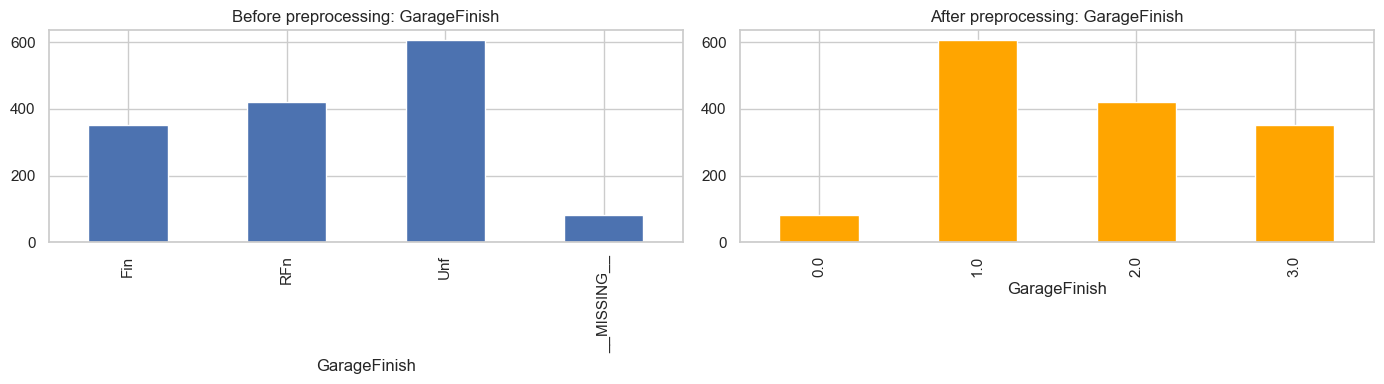

Numeric comparison is not available for: GarageArea


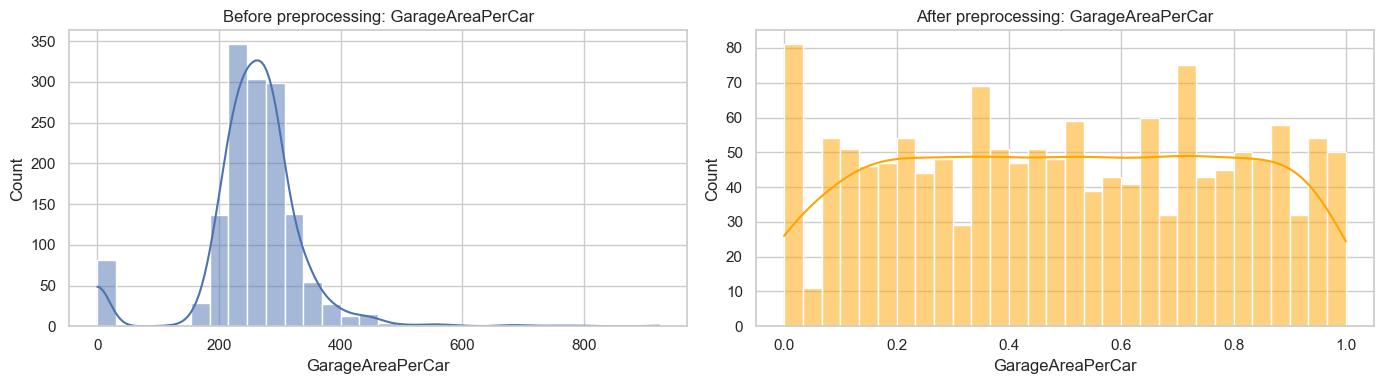

Numeric comparison is not available for: GarageCars


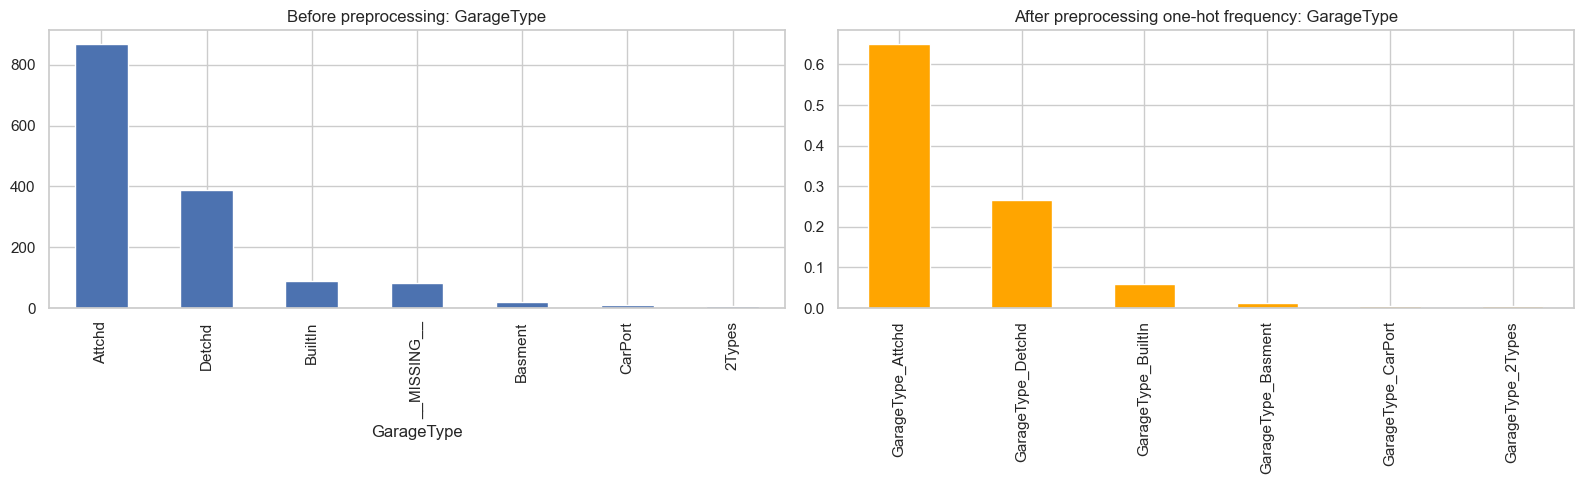

In [88]:
# plot_numeric_before_after("LotArea")
# plot_numeric_before_after("GrLivArea")
plot_ordinal_before_after("GarageFinish")
plot_numeric_before_after("GarageArea")
plot_numeric_before_after("GarageAreaPerCar")

plot_numeric_before_after("GarageCars")
plot_categorical_before_after("GarageType")

## 10. Run The Experiment

When you are happy with the feature and preprocessing choices, run the full experiment. Outputs will be saved under `outputs/experiments/<experiment_name>/`.

In [89]:
result = run_experiment(CONFIG, experiment)
result

,experiment_name,experiment_description,model_name,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,is_best_model,best_model_name,experiment_dir
0,3 - GarageAreaPerCar: transform=log1p,GarageAreaPerCar = GarageArea / GarageCars - n...,random_forest,31741.906512,6908.464593,18252.878366,1392.725262,0.827497,0.092829,True,random_forest,/Users/maksymponomarenko/Documents/ai-engineer...
1,3 - GarageAreaPerCar: transform=log1p,GarageAreaPerCar = GarageArea / GarageCars - n...,linear_regression,32731.328025,7279.405046,18286.681828,1042.937784,0.815399,0.103732,False,random_forest,/Users/maksymponomarenko/Documents/ai-engineer...
2,3 - GarageAreaPerCar: transform=log1p,GarageAreaPerCar = GarageArea / GarageCars - n...,ridge,32735.889419,7860.198031,18115.632259,1024.871897,0.813254,0.114340,False,random_forest,/Users/maksymponomarenko/Documents/ai-engineer...


## 11. Suggested Things To Try

Good preprocessing experiments to learn from:

1. Change `LotArea` from `log1p` to `none`
2. Change `TotalSF` scaling from `robust` to `standard`
3. Set `Neighborhood.min_frequency` to `None` and compare with `0.01`
4. Switch one numeric column from `median` to `mean`
5. Drop a weak feature and see whether metrics change
6. Compare the same preprocessing under `linear_regression`, `ridge`, and `random_forest`